## Setup

In [ ]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER")
sys.path.append(str(PROJECT_DIR))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import seaborn as sns
from Bio import SeqIO

import config
import utils
import stat_utils
import plotting_utils
import models.tf_to_tg as tf_to_tg_module

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CELL_TYPE = "mESC"
SAMPLE_NAME = "E7.5_rep1"
SPECIES = "mouse"
SPECIES_BUILD = config.species_for_cell_type(CELL_TYPE) # mm10 or hg38

training_cache_dir = PROJECT_DIR / "cached_data_old" / SPECIES_BUILD / f"{CELL_TYPE}_cache"

print(f"{SPECIES} / {CELL_TYPE} / {SAMPLE_NAME} on {device}")

In [ ]:
# Enough edges to find a decent number of positives; the cache is TF-major, so a
# small subset can be all one TF. Raise SCAN_EDGES if you want more variety.
SCAN_EDGES = 4096
BATCH_SIZE = 64

loader, metadata, manifest, tf_embeddings_tensor, tf_mask_tensor = utils.load_training_cache_dataset(
    sample_name=SAMPLE_NAME,
    cell_type_cache_dir=training_cache_dir,
    split_type="test",
    subset_size=SCAN_EDGES,
    batch_size=BATCH_SIZE,
)

print("max_peaks_real   :", metadata["max_peaks_real"])
print("max_cells_per_pair:", metadata["max_cells_per_pair"])
print("n test edges     :", manifest["n_test_rows"])
print("tf_embeddings    :", tuple(tf_embeddings_tensor.shape))
print()
example = next(iter(loader))
for key, value in example.items():
    if torch.is_tensor(value):
        print(f"{key:20s} {str(tuple(value.shape)):20s} {value.dtype}")

In [ ]:
def get_all_tf_aa_sequences(tf_seq_dir, tf_names):
    """
    Retrieve the amino acid sequence for a list of transcription factors based on their names.
    
    Requires that the amino acid sequences are stored in a FASTA file named "{TF_NAME}_protein.fasta"
    within the specified directory.
    """
    
    tf_records = {}
    
    for tf_name in tf_names:
        fasta_file = tf_seq_dir / f"{tf_name.capitalize()}_protein.fasta"
        if not fasta_file.exists():
            continue
        
        for record in SeqIO.parse(fasta_file, "fasta"):
            tf_records[tf_name] = (record.id, str(record.seq))
    
    return tf_records
    
    
def get_all_tf_3di_sequences(tf_3di_dir):
    """
    Retrieve the 3Di sequence for a given transcription factor (TF) based on its RefSeq ID.
    
    Requires that the 3Di sequences are stored in a FASTA file named "tf_proteins_3di.fasta" 
    within the specified directory.
    """
    
    tf_3di_sequences = {}
    
    tf_3di_file = tf_3di_dir / "tf_proteins_3di.fasta"
        
    for record in SeqIO.parse(tf_3di_file, "fasta"):
        tf_3di_sequences[record.id] = str(record.seq)

    return tf_3di_sequences


def load_cisbp_motifs(motif_dir, tf_names, direct_only=True, min_ic=0.25, min_len=4):
    """One representative PWM per TF by highest information content (IC)

    direct_only keeps TF_Status == "D". CIS-BP "I" motifs are inferred by copying
    the motif of a TF with a similar DNA-binding domain.
    """
    motif_dir = Path(motif_dir)
    info = pd.read_csv(motif_dir / "TF_Information_all_motifs.txt", sep="\t")
    info["TF_Name"] = info["TF_Name"].str.upper()
    info = info[info["Motif_ID"].notna() & (info["Motif_ID"] != ".")]
    if direct_only:
        info = info[info["TF_Status"] == "D"]
    info = info[info["TF_Name"].isin(set(tf_names))]
    
    def pwm_information_content(pwm):
        """Per-column information content in bits (0 = uniform, 2 = a fixed base)."""
        p = np.clip(pwm, 1e-9, None)
        return 2.0 + (p * np.log2(p)).sum(axis=1)


    def trim_pwm(pwm, min_ic=0.25):
        """Drop uninformative leading/trailing columns.

        Near-uniform flanks make every motif resemble every other motif, because all
        near-uniform columns resemble each other.
        """
        ic = pwm_information_content(pwm)
        keep = np.flatnonzero(ic >= min_ic)
        return pwm if len(keep) == 0 else pwm[keep[0] : keep[-1] + 1]

    pwms, families = {}, {}
    for tf_name, rows in info.groupby("TF_Name"):
        best, best_ic = None, -np.inf
        for motif_id in rows["Motif_ID"].unique():
            path = motif_dir / "pwms_all_motifs" / f"{motif_id}.txt"
            if not path.exists():
                continue
            mat = pd.read_csv(path, sep="\t", index_col=0).values.astype(float)
            if mat.ndim != 2 or mat.shape[1] != 4 or mat.shape[0] < min_len:
                continue
            mat = mat / np.clip(mat.sum(axis=1, keepdims=True), 1e-9, None)
            mat = trim_pwm(mat, min_ic=min_ic)
            total_ic = pwm_information_content(mat).sum()
            if total_ic > best_ic:
                best, best_ic = mat, total_ic
        if best is not None and len(best) >= min_len:
            pwms[tf_name] = best
            families[tf_name] = rows["Family_Name"].iloc[0]
    return pwms, families


def load_dbd_locations(domain_csv, sources=("uniprot_feature", "interpro_pfam")):
    """{TF_NAME: [(start, end), ...]}, 1-based inclusive, overlaps merged.

    Merging matters: a DBD called by both UniProt and Pfam would otherwise have its
    shared residues counted twice in the mean.
    """
    table = pd.read_csv(domain_csv)
    table["tf_name"] = table["tf_name"].str.upper()
    table = table[table["is_dbd"] & table["source"].isin(sources)]

    intervals = {}
    for tf_name, group in table.groupby("tf_name"):
        tf_name = tf_name.upper()
        merged = []
        for start, end in sorted(zip(group["start"], group["end"])):
            if merged and start <= merged[-1][1] + 1:
                merged[-1][1] = max(merged[-1][1], end)
            else:
                merged.append([start, end])
        intervals[tf_name] = merged
    return intervals


def cached_residues(cache_dir):
    """TF name -> its [L, 128] residue embeddings, padding stripped."""
    cache_dir = Path(cache_dir)
    emb = torch.load(cache_dir / "tf_embeddings.pt", map_location="cpu", weights_only=False).float()
    mask = torch.load(cache_dir / "tf_masks.pt", map_location="cpu", weights_only=False).bool()
    order = pd.read_csv(cache_dir / "tf_name_to_idx.csv").sort_values("tf_idx")["tf_name"].str.upper()
    row_of = {name: i for i, name in enumerate(order)}

    def residues(tf_name):
        tf_name = tf_name.upper()
        if tf_name not in row_of:
            return None
        row = row_of[tf_name]
        return emb[row][: int(mask[row].sum())]

    return residues


def pool_over_dbd(residues_for, intervals, tf_names):
    """
    Mean-pool each TF embedding over its DBD residues only.

    Returns:
        vectors: [N, embedding_dim]
        covered: TF names successfully pooled
    """

    vectors = []
    covered = []

    for tf_name in tf_names:
        tf_name = tf_name.upper()

        spans = intervals.get(tf_name)
        residues = residues_for(tf_name)

        if not spans:
            continue

        if residues is None:
            continue

        if spans[-1][1] > len(residues):
            print(
                f"{tf_name}: DBD coordinates exceed sequence length "
                f"(DBD end={spans[-1][1]}, sequence length={len(residues)})"
            )
            continue

        dbd_residues = torch.cat([residues[start - 1:end] for start, end in spans])
        pooled = dbd_residues.mean(dim=0).numpy()

        vectors.append(pooled)
        covered.append(tf_name)

    if not vectors:
        embedding_dim = 128
        return np.empty((0, embedding_dim)), covered

    return np.stack(vectors), covered


def print_tf_info(tf_name, tf_info):
    if tf_name not in tf_info:
        print(f"No information available for TF: {tf_name}")
        return
    else:
        info = tf_info[tf_name]
        print(f"TF: {tf_name}")
        print(f"  TF idx: {info['tf_idx']}")
        print(f"  Fasta RefSeq ID: {info['tf_refseq_id']}")
        print(f"  Amino Acid Sequence: {info['tf_aa_sequence'][:10]}...{info['tf_aa_sequence'][-10:]}")
        print(f"  3Di Sequence: {info['tf_3di_sequence'][:10]}...{info['tf_3di_sequence'][-10:]}")
        print(f"  Protein sequence length: {info['tf_embedding'].shape[0]}")
        print(f"  Embedding dimension size: {info['tf_embedding'].shape[1]}")
        if info['tf_cisbp_pwms'] is not None:
            print(f"  Motif PWM: {info['tf_cisbp_pwms'] is not None} (shape: {info['tf_cisbp_pwms'].shape})")
        else:
            print(f"  Motif PWM: None")
            
        if info["tf_dbd_locations"] is not None:
            print(f"  DBD locations: {info['tf_dbd_locations']}")
        else:
            print("  DBD locations: None")

        if info["mean_pooled_dbd_embedding"] is not None:
            print(
                "  Mean pooled DBD embedding shape: "
                f"{info['mean_pooled_dbd_embedding'].shape}"
            )
        else:
            print("  Mean pooled DBD embedding: None")
        
        if info['tf_dbd_families'] is not None:
            print(f"  Motif Family: {info['tf_dbd_families']}")
        else:
            print(f"  Motif Family: None")


def plot_tf_embedding_heatmap(tf_name, tf_info, use_dbd=False):
    

    selected_tf_emb_seq = tf_info[tf_name]["tf_embedding"].numpy()
    
    cols_original_seq = selected_tf_emb_seq.shape[0]
    cols_new_seq = None
    
    should_use_dbd = [
        tf_info[selected_tf_name]["tf_dbd_locations"] is not None,
        tf_info[selected_tf_name]["tf_dbd_families"] is not None,
        use_dbd
    ]
    
    if all(should_use_dbd):
        motif_family = tf_info[selected_tf_name]["tf_dbd_families"]
        start = tf_info[selected_tf_name]["tf_dbd_locations"][0][0] - 1  # Convert to 0-based index
        end = tf_info[selected_tf_name]["tf_dbd_locations"][0][1]  # End is inclusive in the original data
        title = f"{tf_name} Embedding\nDBD {motif_family} [{start}:{end}]"
        
        if start is not None and end is not None:
            selected_tf_emb_seq = selected_tf_emb_seq[start:end]
            cols_new_seq = selected_tf_emb_seq.shape[0]
            
    else:
        title = f"{tf_name} Embedding"
    
    original_width = 10
    frac_cols_new_seq = cols_new_seq / cols_original_seq if cols_new_seq is not None else 1.0
    width = original_width * frac_cols_new_seq if cols_new_seq is not None else original_width
    
    fig, ax = plt.subplots(figsize=(width, 6))

    sns.heatmap(
        selected_tf_emb_seq.T,
        cmap="viridis",
        ax=ax,
        xticklabels=False,
        yticklabels=False,
        cbar=False,
    )

    ax.set(
        xlabel=f"TF AA position ({selected_tf_emb_seq.shape[0]})",
        ylabel=f"Embedding dimension ({selected_tf_emb_seq.shape[1]})",
        title=title,
    )

    ax.xaxis.set_label_position('top')

    return fig


def plot_tf_mean_pooled_embedding_heatmap(tf_name, tf_info):
    fig, ax = plt.subplots(figsize=(0.1, 6))

    mean_pooled_embedding = tf_info[tf_name]["mean_pooled_dbd_embedding"]
    
    if mean_pooled_embedding is None:
        print(f"No mean pooled DBD embedding available for TF: {tf_name}")
        return fig

    sns.heatmap(
        mean_pooled_embedding.reshape(1, -1).T,  # Reshape to 2D for heatmap
        cmap="viridis",
        ax=ax,
        xticklabels=False,
        yticklabels=False,
        cbar=False,
    )

    ax.set(
        xlabel=f"1",
        ylabel=f"Mean Pooled DBD ({mean_pooled_embedding.shape[0]})",
        title=f"{tf_name}\nMean Pooled DBD Embedding",
    )

    ax.xaxis.set_label_position('top')

    return fig

In [ ]:
tf_to_id = metadata["tf_name_to_idx"]
id_to_tf = {v: k for k, v in tf_to_id.items()}

TF_DATA_DIR = PROJECT_DIR.parent / "data" / "tf_data" / SPECIES_BUILD
TF_MOTIF_DIR = PROJECT_DIR.parent / "data" / "databases" / "motif_information" / SPECIES_BUILD
EMB_CACHE = PROJECT_DIR / "cached_data" / SPECIES_BUILD / "tf_dna_cache"

tf_seq_dir = TF_DATA_DIR / "tf_sequences"
tf_3di_dir = TF_DATA_DIR / "tf_3di_output"
tf_dbd_file = TF_DATA_DIR / "tf_domains.csv"

tf_names = tf_to_id.keys()

cisbp_records = get_all_tf_aa_sequences(tf_seq_dir, tf_names)

tf_3di_sequences = get_all_tf_3di_sequences(tf_3di_dir)

tf_cisbp_pwms, tf_families = load_cisbp_motifs(TF_MOTIF_DIR, tf_names, direct_only=True, min_ic=0.25, min_len=4)
tf_dbd_locations = load_dbd_locations(tf_dbd_file, sources=("uniprot_feature", "interpro_pfam"))

residues_for = cached_residues(EMB_CACHE)
mean_pooled_dbd_embeddings, covered_tfs = pool_over_dbd(residues_for, tf_dbd_locations, tf_names)

tf_info = {}
for tf_name in tf_names:
    tf_info[tf_name] = {}

    refseq_id, aa_sequence = cisbp_records.get(tf_name, (None, None))
    tf_emb_residues = residues_for(tf_name)

    tf_info[tf_name]["tf_idx"] = tf_to_id[tf_name]
    tf_info[tf_name]["tf_refseq_id"] = refseq_id
    tf_info[tf_name]["tf_aa_sequence"] = aa_sequence
    tf_info[tf_name]["tf_3di_sequence"] = tf_3di_sequences.get(refseq_id, None)
    tf_info[tf_name]["tf_cisbp_pwms"] = tf_cisbp_pwms.get(tf_name, None)
    tf_info[tf_name]["tf_dbd_families"] = tf_families.get(tf_name, None)
    tf_info[tf_name]["tf_dbd_locations"] = tf_dbd_locations.get(tf_name, None)
    tf_info[tf_name]["tf_embedding"] = tf_emb_residues
    tf_info[tf_name]["mean_pooled_dbd_embedding"] = (
        mean_pooled_dbd_embeddings[covered_tfs.index(tf_name.upper())] if tf_name.upper() in covered_tfs else None
        )

TF: ARID5A
  TF idx: 0
  Fasta RefSeq ID: NP_001165676.1
  Amino Acid Sequence: MAAPPAKGNT...PHFFHLNTKL
  3Di Sequence: DDDDDDDDDD...VSVVDDPDVD
  Protein sequence length: 590
  Embedding dimension size: 128
  Motif PWM: True (shape: (8, 4))
  DBD locations: [[53, 137]]
  Mean pooled DBD embedding shape: (128,)
  Motif Family: ARID/BRIGHT


TF: ARID5A
  TF idx: 0
  Fasta RefSeq ID: NP_001165676.1
  Amino Acid Sequence: MAAPPAKGNT...PHFFHLNTKL
  3Di Sequence: DDDDDDDDDD...VSVVDDPDVD
  Protein sequence length: 590
  Embedding dimension size: 128
  Motif PWM: True (shape: (8, 4))
  DBD locations: [[53, 137]]
  Mean pooled DBD embedding shape: (128,)
  Motif Family: ARID/BRIGHT


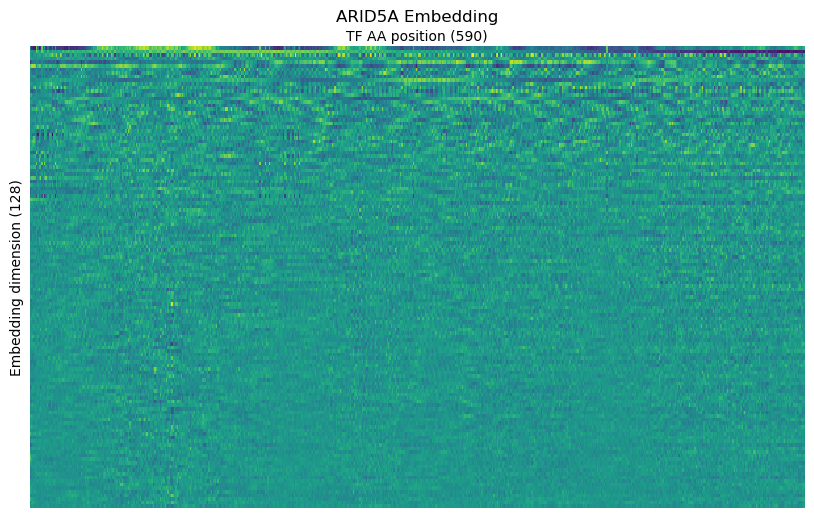

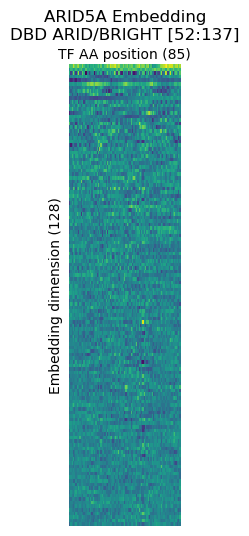

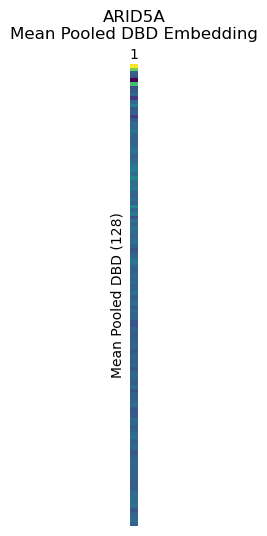

In [ ]:
selected_tf = 0
selected_tf_name = id_to_tf[selected_tf]
print_tf_info(selected_tf_name, tf_info)

fig = plot_tf_embedding_heatmap(selected_tf_name, tf_info)
fig.show()

if tf_info[selected_tf_name]["tf_dbd_locations"] is not None and tf_info[selected_tf_name]["tf_dbd_families"] is not None:
    dbd_fig = plot_tf_embedding_heatmap(selected_tf_name, tf_info, use_dbd=True)
    dbd_fig.show()
    
mean_pooled_fig = plot_tf_mean_pooled_embedding_heatmap(selected_tf_name, tf_info)
mean_pooled_fig.show()

## TF Embedding and motif similarity

If the TF embeddings capture rich meaning about the DNA binding preferences of TFs, then 
TFs from the same family and with similar DNA binding motifs should have similar embeddings.

In this section, we compare the TF embeddings of the DNA binding domain (DBD) regions to 
determine if within-family TF embeddings are more similar than between-family TF embeddings.
We further verify that TF embeddings have similar DNA binding preferences by comparing whether
similar TF embeddings have similar DNA binding motifs.

**Steps:**
**1. Determine DBDs for each TF to compare embeddings**

The protein lengths vary widely. Mean pooling the embeddings across the entire protein sequence
would over-compress the information in the embeddings. We can reduce the variation in the size
of sequences that we are pooling by only looking at the TF embeddings at the DBDs.

The DBD coordinates are created using `scripts/fetch_tf_domains.py`, which maps each RefSeq accession
number from the Cis-BP `TF_Information_all_motifs.txt` to UniProt and fetches the DBDs from UniProt's
SwissProt curated features and InterPro's Pfam matches. Only TFs with directly annotated DBDs (Cis-BP's
 `TF_Status` = `D`) are used. Inferred DBDs (`TF_Status` = `I`) copies the motif from another TF with 
a similar DBD.

**2. Remove the padding from the TF sequence length**

The sequence length dimension of the TF embeddings are padded to several dimension sizes. This is a 
middle-ground between padding to the longest tensor and not having any padding. If all of the inputs
are the same size, the trained model can be compiled to run much faster. A compiled model requires 
all inputs to have exactly the same shape, or else the model needs to re-compile. If we pad to the 
longest TF sequence, then we waste a lot of computation by passing very large tensors into the model
that we end up masking out. If we pass in each TF embedding with no padding, then we can't compile the 
model. We use a ladder of several different padding sizes, then pass in all batches from the same rung 
before switching to the next size. This reduces the size of the data and greatly improves runtime, 
while only requiring the model to re-compile a few times (once per size increase).

**3. Mean pool embeddings for each TF's DBD**

The TF's embeddings are mean pooled across the DBD residue locations from the output of 
`scripts/fetch_tf_domains.py`. This reduces the shape from [DBD_len, 128] to [1, 128] so that we can
compare the embedding dimensions from TFs with differently sized DBDs.

**4. Calculate cosine similarity between the 128-d mean pooled TF DBD embeddings**

The cosine similarity measures the similarity between the angle of two N-dimensional vectors

$$\cos(a,b) = \frac{a \cdot b}{||a||,||b||}$$

+1: same vector direction
0: unrelated
-1: opposite vector direction

Dividing by the lengths of A and B normalizes the vectors to only compare the *direction*, not the *magnitude*.

**5. Calculate the similarity between the PWMs**




In [ ]:
def plot_similarity_heatmap(similarity_matrix, mask_lower_triangle=False):
    """
    Plot a heatmap of the cosine similarity between mean-pooled DBD embeddings.
    
    Args:
        similarity_matrix (np.ndarray): A square matrix of cosine similarities.
        mask_lower_triangle (bool): A boolean specify whether to hide the lower triangle of the heatmap.
    """
    if mask_lower_triangle is True:
        mask_lower_triangle = np.tril(
            np.ones_like(similarity_matrix, dtype=bool),
            k=0,
        )
    else:
        mask_lower_triangle = None

    fig, ax = plt.subplots(figsize=(4, 4))
    sns.heatmap(
        similarity_matrix,
        mask=mask_lower_triangle,
        cmap="viridis",
        cbar_kws={"label": "Cosine Similarity"},
        ax=ax,
        xticklabels=False,
        yticklabels=False,
        cbar=False,
        square=True
    )

    ax.set(
        xticks=[],
        yticks=[],
    )

    ax.set_title("Cosine Similarity of Mean-Pooled DBD Embeddings")
    plt.tight_layout()
    return fig

We will compare the similarity between all TFs with both TF embeddings and PWMs

In [ ]:
shared_tfs = [tf for tf in covered_tfs if tf in tf_cisbp_pwms]

tf_to_embedding_idx = {tf: i for i, tf in enumerate(covered_tfs)}

shared_embedding_idx = [tf_to_embedding_idx[tf] for tf in shared_tfs]

shared_dbd_embeddings = mean_pooled_dbd_embeddings[shared_embedding_idx]

Calculate the pairwise cosine similarity between each TF's mean pooled DBD embedding. We mask out the lower triangle of the similarity matrix so that we don't count comparisons twice.

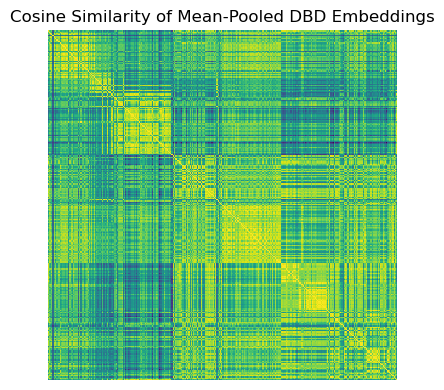

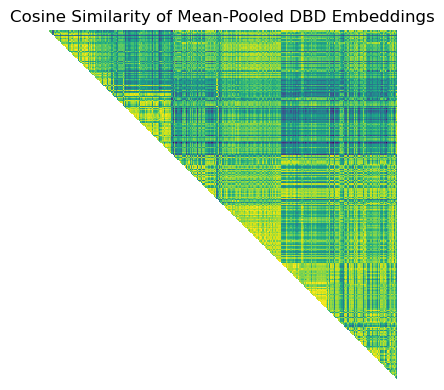

In [ ]:
# Calculate the cosine similarity between mean-pooled DBD embeddings
# cosine similarity = (A . B) / (||A|| * ||B||)
# This will give us a similarity matrix where each entry (i, j) represents the cosine similarity
# between the mean-pooled DBD embeddings of TF i and TF j.
X = shared_dbd_embeddings / np.linalg.norm(shared_dbd_embeddings, axis=1, keepdims=True)
embedding_similarity = X @ X.T

emb_similarity_heatmap_fig = plot_similarity_heatmap(embedding_similarity)
emb_similarity_heatmap_fig.show()

# Get the upper triangular indices of the similarity matrix to avoid duplicate pairs and self-similarity
upper = np.triu_indices(len(shared_tfs), k=1)
emb_sim_pairs = embedding_similarity[upper]

masked_emb_similarity_heatmap_fig = plot_similarity_heatmap(embedding_similarity, mask_lower_triangle=True)
masked_emb_similarity_heatmap_fig.show()

Likewise, we need to get the similarity between the TF PWMs. The PWMs can have a variable number of bases and could match either forward or reverse, so we need to account for these factors. We calculate the similarity for each PWM by sliding the sequence of one along the sequence of another and calculating the Pearson correlation. This is repeated for the reverse complement alignment and the maximum correlation is set as the similarity.

In [ ]:
def all_pairs_pwm_similarity(pwm_list):
    """[N, N] best-alignment motif similarity in [-1, 1]; 1.0 == identical motif.

        score(shift) = sum_i pearson(a[i + shift], b[i]) / (len_a + len_b - overlap)

    maximised over every ungapped shift and both strands. The union-length
    denominator charges for the non-overlapping tails, so a short chance match
    between two long motifs cannot outscore a real full-length match.

    Vectorised as one matmul per (shift, strand) -- ~13 s for 360 motifs, versus
    hours for a Python loop over pairs.
    """
    lens = np.array([len(p) for p in pwm_list])
    pad = int(lens.max())
    n = len(pwm_list)
    
    def _encode_pwms(pwms, pad):
        """[N, pad, 4] centered + unit-normalised columns, plus [N, pad] real-column mask.

        Centering each column makes a per-column dot product exactly the Pearson
        correlation of the two 4-vectors. Cosine on raw probabilities instead scores
        every pair of near-uniform columns at ~1.0.
        """
        Z = np.zeros((len(pwms), pad, 4))
        M = np.zeros((len(pwms), pad))
        for i, pwm in enumerate(pwms):
            col = pwm - pwm.mean(axis=1, keepdims=True) # Center each column by subtracting its mean
            
            # Normalize each position to unit length (z = (xi - mean) / ||xi - mean||)
            # (dot product between two centered and normalized columns is the Pearson correlation)
            nrm = np.linalg.norm(col, axis=1, keepdims=True) 
            Z[i, : len(pwm)] = np.divide(col, nrm, out=np.zeros_like(col), where=nrm > 1e-12)
            
            # Pad the mask to indicate which columns are real (1) and which are padded (0)
            # based on the max length of the PWMs
            M[i, : len(pwm)] = 1.0
        return Z, M

    # Encode the PWMs and their reverse complements
    Zf, M = _encode_pwms(pwm_list, pad)
    Zr, _ = _encode_pwms([p[::-1, ::-1] for p in pwm_list], pad)  # reverse complement

    # Calculate Pearson correlation for each pair of PWMs, considering all shifts and both strands
    len_sum = lens[:, None] + lens[None, :] # Denominator for each comparison: len_a + len_b - overlap
    best = np.full((n, n), -np.inf)

    for Z_other in (Zf, Zr): # Compare forward and reverse complement
        B = Z_other.reshape(n, -1) # flatten for matrix multiplication (N, pad, 4) -> (N, pad*4)
        
        # Try every possible sliding window shift between the two PWMs
        for shift in range(-(pad - 1), pad):
            Zs, Ms = np.zeros_like(Zf), np.zeros_like(M)
            
            # Get the overlapping region of the two PWMs based on the current shift
            if shift >= 0:
                Zs[:, shift:], Ms[:, shift:] = Zf[:, : pad - shift], M[:, : pad - shift]
            else:
                Zs[:, : pad + shift], Ms[:, : pad + shift] = Zf[:, -shift:], M[:, -shift:]
                
            # Calculate the overlap as the dot product of the masks (number of overlapping columns)
            overlap = Ms @ M.T
            
            # Calculate the score for each pair of PWMs based on the dot product of the encoded columns
            score = (Zs.reshape(n, -1) @ B.T) / np.maximum(len_sum - overlap, 1.0)
            
            # Update the best score for each pair of PWMs if the current score is higher
            np.maximum(best, score, out=best)

    # Fill the diagonal with 1.0 since each PWM is identical to itself
    np.fill_diagonal(best, 1.0)
    return best

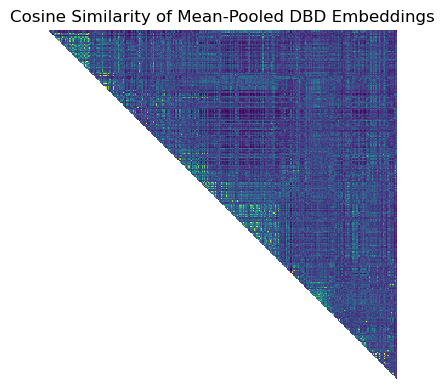

In [ ]:
pwm_list = [tf_cisbp_pwms[tf] for tf in shared_tfs]

# Calculate the cosine similarity between all pairs of PWMs using the Pearson correlation
# for the best-alignment
motif_similarity = all_pairs_pwm_similarity(pwm_list)

# Only keep the upper triangular part of the similarity matrix to avoid duplicate pairs
upper = np.triu_indices(len(shared_tfs), k=1)
pwm_sim_pairs = motif_similarity[upper]

pwm_similarity_heatmap_fig = plot_similarity_heatmap(motif_similarity, mask_lower_triangle=True)
pwm_similarity_heatmap_fig.show()

Next, we want to designate whether the TFs are from the same family or different families. We want TFs from the same family to have similar embeddings.

In [ ]:
tf_family = np.array([tf_families[tf] for tf in shared_tfs])

same_family = (tf_family[:, None] == tf_family[None, :])[upper]

print(f"{len(emb_sim_pairs):,} TF pairs ({same_family.sum():,} same-family)")

print(f"{len(shared_tfs)} TFs with both a DBD-pooled embedding and a direct motif")
print(f"  {len(set(tf_family))} DBD families, motif lengths {min(map(len, pwm_list))}-{max(map(len, pwm_list))} bp")

41,328 TF pairs (3,262 same-family)
288 TFs with both a DBD-pooled embedding and a direct motif
  41 DBD families, motif lengths 4-29 bp


In [ ]:
print("embedding_similarity:", embedding_similarity.shape)
print("motif_similarity:", motif_similarity.shape)
print("tf_family:", len(tf_family))

embedding_similarity: (288, 288)
motif_similarity: (288, 288)
tf_family: 288


We will use the Mantel test to measure the correlation between the two similarity matrices.

The Mantel test calculates the Spearman correlation between two matrices of the same size. To determine
whether the observed correlation is significant, the rows and columns of one matrix are randomly permuted
many times to generate a null distribution of correlations. 

For this test, the null hypothesis is that the DBD embedding similarities does not correlate with PWM similarity.
The alternative hypothesis is that TFs with similar DBD embeddings have similar PWMs

In [ ]:
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr

def mantel_test(sim_a, sim_b, n_perm=999, seed=0):
    """
    Measure the correlation between two matrices of the same dimension.
    
    Spearman rho with a permutation p-value that respects pair dependence.

    The N*(N-1)/2 pairs are not independent observations -- every TF appears in
    N-1 of them -- so an ordinary correlation p-value is far too small. Permuting
    whole TF labels (rows and columns together) preserves that structure.
    """
    upper = np.triu_indices(len(sim_a), k=1)
    
    # Compute the observed Spearman correlation between the two similarity matrices
    observed_spearman = spearmanr(sim_a[upper], sim_b[upper]).statistic
    
    # Randomly permute the rows and columns of sim_a to generate null distributions
    # Calculate the Spearman correlation for each permutation and store it in the null array
    rng = np.random.default_rng(seed)
    null_spearman = np.empty(n_perm)
    for i in range(n_perm):
        p = rng.permutation(len(sim_a))
        null_spearman[i] = spearmanr(sim_a[np.ix_(p, p)][upper], sim_b[upper]).statistic
        
    # Calculate the p-value as the proportion of null Spearman correlations that are greater than 
    # or equal to the observed Spearman correlation
    p_value = (np.sum(null_spearman >= observed_spearman) + 1) / (n_perm + 1)
    
    return observed_spearman, p_value, null_spearman


def report_agreement(emb_sim, pwm_sim, family, label):
    # Mask the lower triangle to avoid duplicate pairs and self-similarity
    upper_triangle_mask = np.triu_indices(len(family), k=1)
    x, y = emb_sim[upper_triangle_mask], pwm_sim[upper_triangle_mask]
    
    # Create a boolean mask for TFs in the same family
    same = (family[:, None] == family[None, :])[upper_triangle_mask]
    
    observed_spearman_rho, p_value, null_spearman_rho = mantel_test(emb_sim, pwm_sim)

    # Nearest embedding neighbour: the most directly interpretable framing.
    masked = emb_sim.copy()
    np.fill_diagonal(masked, -np.inf)
    nn = masked.argmax(axis=1)

    print(f"--- {label} ---")
    print(f"  Spearman rho btw embeddings and motifs     {observed_spearman_rho:+.3f}   Mantel p = {p_value:.4f}")
    print(f"  AUROC, ranking top-1% motif-similar pairs  {roc_auc_score(y >= np.quantile(y, 0.99), x):.3f}")
    print(f"  AUROC, ranking same-family pairs           {roc_auc_score(same, x):.3f}")
    print(f"  Spearman rho within family                 {spearmanr(x[same], y[same]).statistic:+.3f}  (n={same.sum():,})")
    print(f"  Spearman rho between families              {spearmanr(x[~same], y[~same]).statistic:+.3f}  (n={(~same).sum():,})")
    print(f"  motif sim. of nearest embedding neighbour  {pwm_sim[np.arange(len(family)), nn].mean():.3f}"
          f"  vs {y.mean():.3f} for a random pair")
    print(f"  nearest embedding neighbour, same family   {(family[nn] == family).mean() * 100:.1f}%")


report_agreement(embedding_similarity, motif_similarity, tf_family, "DBD-pooled embeddings vs direct motifs")

--- DBD-pooled embeddings vs direct motifs ---
  Spearman rho btw embeddings and motifs     +0.129   Mantel p = 0.0010
  AUROC, ranking top-1% motif-similar pairs  0.820
  AUROC, ranking same-family pairs           0.861
  Spearman rho within family                 +0.255  (n=3,262)
  Spearman rho between families              +0.048  (n=38,066)
  motif sim. of nearest embedding neighbour  0.502  vs 0.233 for a random pair
  nearest embedding neighbour, same family   87.8%


Looking at every pairwise comparison, there was a modest but significant correlation between TF embedding and 
PWM similarity ($\text{Spearman } \rho = 0.129, \text{Mantel } p = 0.001$). This correlation was much stronger within TF DBD families ($\rho$ = 0.255) than between TF DBD families ($\rho = 0.048$). The DBD embedding similarity between TFs was alo able to strongly predict TF DBD family membership (AUROC = 0.861). The nearest neighbor of each TF embedding's similarity was from same DBD family 87.8% of the time. These results indicate that the TF embeddings encode rich information about the DNA binding preferences of a TF from the amino acid sequence and 3Di structure. The TF-DNA binding model has demonstrated a remarkable ability to generalize to unseen TFs, likely due to the model learning to interpret the information from these embeddings.

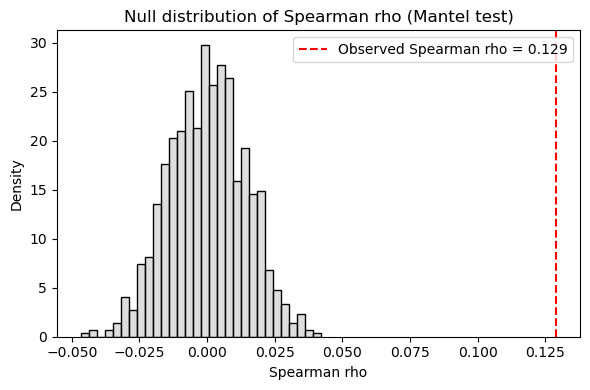

In [ ]:
# Mask the lower triangle to avoid duplicate pairs and self-similarity
upper_triangle_mask = np.triu_indices(len(tf_family), k=1)
x, y = embedding_similarity[upper_triangle_mask], motif_similarity[upper_triangle_mask]

# Create a boolean mask for TFs in the same family
same = (tf_family[:, None] == tf_family[None, :])[upper_triangle_mask]

observed_spearman_rho, p_value, null_spearman_rho = mantel_test(embedding_similarity, motif_similarity)
print(null_spearman_rho.shape)

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(
    null_spearman_rho,
    bins=30,
    color="lightgray",
    stat="density",
    ax=ax,
)

plt.axvline(observed_spearman_rho, color="red", linestyle="--", label=f"Observed Spearman rho = {observed_spearman_rho:.3f}")
plt.title("Null distribution of Spearman rho (Mantel test)")
plt.xlabel("Spearman rho")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

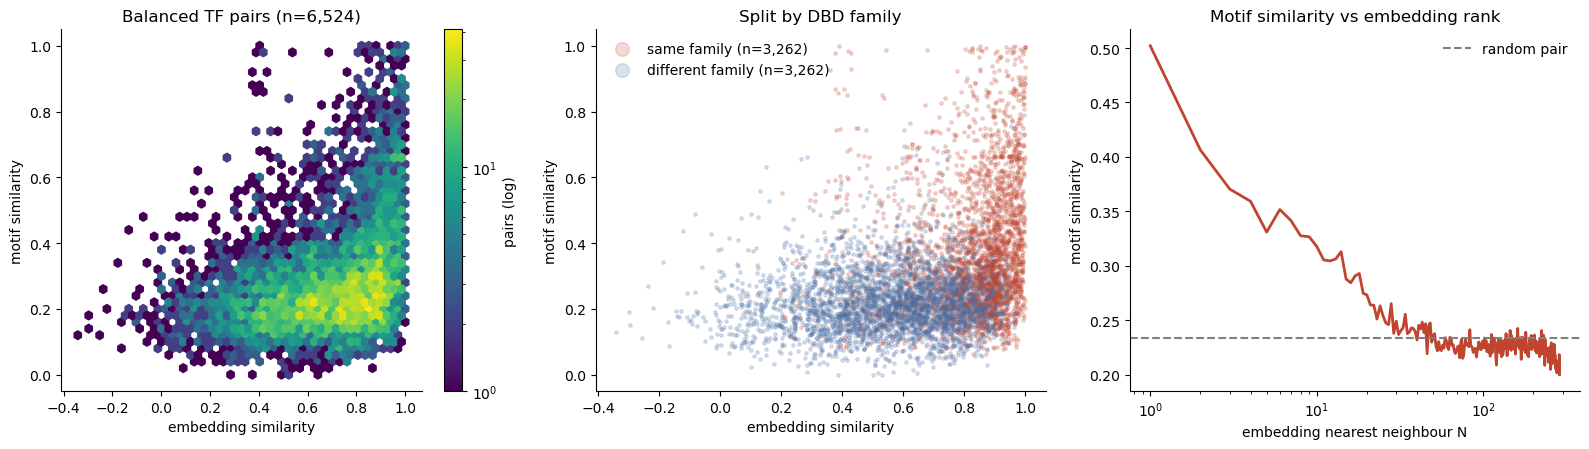

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

rng = np.random.default_rng(42)

same_idx = np.flatnonzero(same_family)
diff_idx = np.flatnonzero(~same_family)
n = min(len(same_idx), len(diff_idx))

same_sampled = rng.choice(same_idx, n, replace=False)
diff_sampled = rng.choice(diff_idx, n, replace=False)
balanced_idx = np.concatenate([same_sampled, diff_sampled])

# 1. Balanced all-pairs hexbin
hb = axes[0].hexbin(
    emb_sim_pairs[balanced_idx],
    pwm_sim_pairs[balanced_idx],
    gridsize=45,
    bins="log",
    cmap="viridis",
    mincnt=1,
)
axes[0].set(
    xlabel="embedding similarity",
    ylabel="motif similarity",
    title=f"Balanced TF pairs (n={2*n:,})",
)
fig.colorbar(hb, ax=axes[0], label="pairs (log)")

# 2. Same-family vs different-family
groups = [
    (same_sampled, "same family", "#c1442e"),
    (diff_sampled, "different family", "#4a6fa5"),
]

for idx, label, colour in groups:
    x, y = emb_sim_pairs[idx], pwm_sim_pairs[idx]

    axes[1].scatter(
        x, y, s=6, alpha=0.20, color=colour,
        label=f"{label} (n={n:,})", rasterized=True
    )

axes[1].set(
    xlabel="embedding similarity",
    ylabel="motif similarity",
    title="Split by DBD family",
)
axes[1].legend(frameon=False, markerscale=4)

# 3. Motif similarity by embedding-neighbour rank
order = np.argsort(-embedding_similarity, axis=1)[:, 1:]
ranked = np.take_along_axis(motif_similarity, order, axis=1)

axes[2].plot(
    np.arange(1, ranked.shape[1] + 1),
    ranked.mean(axis=0),
    lw=2,
    color="#c1442e",
)
axes[2].axhline(
    pwm_sim_pairs.mean(),
    ls="--",
    color="grey",
    label="random pair",
)
axes[2].set(
    xscale="log",
    xlabel="embedding nearest neighbour N",
    ylabel="motif similarity",
    title="Motif similarity vs embedding rank",
)
axes[2].legend(frameon=False)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

Overall, there is a weak correlation between motif similarity and embedding cosine. However, if we split the pairs by within-family and between-family we see that the embedding and motif similarities are higher for TFs in the same family but variable for TFs from different families. The third plot shows that the nearest neighbors in the embedding similarity plot are more likely have similar motifs.